In [ ]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# LOAD & PREPARE DATA
 
# Read the cleaned NVIDIA daily closing-price
nvidia_data = pd.read_csv("NVDA_yfinance_clean.csv", parse_dates=["Date"])
 
# Use 'Date' as the time-series index and sort chronologically
nvidia_data = nvidia_data.set_index("Date").sort_index()
 
nvidia_close_prices = nvidia_data["Close"]
 
print(f"Data loaded: {len(nvidia_close_prices)} trading days "
      f"({nvidia_close_prices.index.min().date()} to "
      f"{nvidia_close_prices.index.max().date()})")

Data loaded: 2514 trading days (2016-01-04 to 2025-12-31)


In [ ]:
# TRAIN / TEST SPLIT
 
# The test window is the most recent 30 trading days in the dataset
test_window = 30
 
# Training set: everything before the last 30 days
train_close_prices = nvidia_close_prices.iloc[:-test_window]
 
# Test set: the last 30 trading days (Dec 2025 dates)
test_close_prices = nvidia_close_prices.iloc[-test_window:]
 
print(f"Train: {train_close_prices.index.min().date()} to {train_close_prices.index.max().date()}")
print(f"Test : {test_close_prices.index.min().date()} to {test_close_prices.index.max().date()}")

Train: 2016-01-04 to 2025-11-17
Test : 2025-11-18 to 2025-12-31


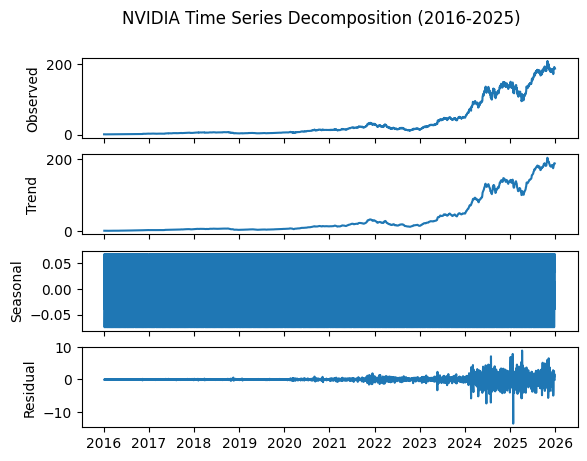

In [ ]:
# TIME-SERIES DECOMPOSITION
 
# Decompose the full price series into trend, seasonal, and residual components
decomposition_result = seasonal_decompose(
    nvidia_close_prices,
    model="additive",
    period=5        # 5 trading days = 1 week
)
 
# Build a 4-panel figure: Observed, Trend, Seasonal, Residual
fig, axes = plt.subplots(4, 1, sharex=True)
fig.suptitle("NVIDIA Time Series Decomposition (2016-2025)")
 
axes[0].plot(nvidia_close_prices)
axes[0].set_ylabel("Observed")
 
axes[1].plot(decomposition_result.trend)
axes[1].set_ylabel("Trend")
 
axes[2].plot(decomposition_result.seasonal)
axes[2].set_ylabel("Seasonal")
 
axes[3].plot(decomposition_result.resid)
axes[3].set_ylabel("Residual")
 
plt.show()
plt.close()


In [ ]:
# FIT EXPONENTIAL SMOOTHING MODEL
 
# Holt's Linear Exponential Smoothing: captures level + additive trend
# seasonal=None because NVDA shows no strong periodic seasonal pattern
exponential_smoothing_model = ExponentialSmoothing(
    train_close_prices,
    trend="add",        # additive trend component
    seasonal=None,      # no seasonal component
    initialization_method="estimated"
)
 
# Fit the model: statsmodels selects optimal alpha and beta via MLE
fitted_es_model = exponential_smoothing_model.fit(optimized=True)
 
print(f"Alpha (level): {fitted_es_model.params['smoothing_level']:.4f}")
print(f"Beta  (trend): {fitted_es_model.params['smoothing_trend']:.4f}")

Alpha (level): 0.9222
Beta  (trend): 0.0000


c:\Users\sumay\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# FORECAST: TEST PERIOD (30 days) + EXTENDED 30 DAYS
 
# Forecast 60 steps ahead: first 30 cover the test period, next 30 extend
# into Jan 2026 (beyond the last observed data point of Dec 31, 2025)
total_forecast_steps = test_window * 2  # 60
 
raw_forecast_values = fitted_es_model.forecast(steps=total_forecast_steps)
 
# Split forecast into two named segments
forecast_for_test_period  = raw_forecast_values.iloc[:test_window]   # Dec 2025
forecast_extended_jan2026 = raw_forecast_values.iloc[test_window:]   # Jan 2026
 
# accuracy metrics and the plot compare apples to apples
forecast_for_test_period.index = test_close_prices.index
 
# Build business-day dates for the Jan 2026 extension
last_observed_date = nvidia_close_prices.index[-1]
extended_dates = pd.bdate_range(
    start=last_observed_date + pd.Timedelta(days=1),
    periods=test_window
)
forecast_extended_jan2026.index = extended_dates

c:\Users\sumay\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\sumay\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


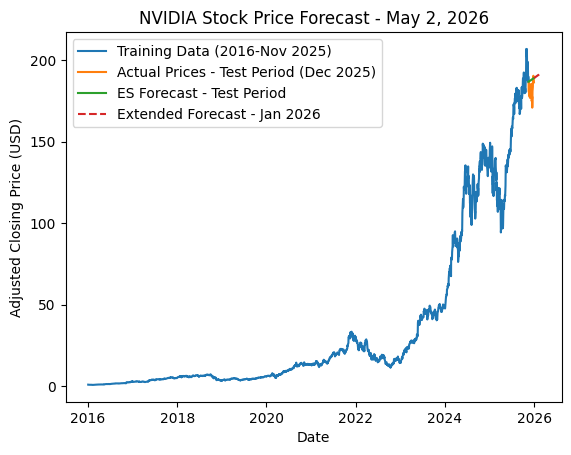

In [ ]:
# FORECAST PLOT
 
fig, ax = plt.subplots()
 
# Training data — full history gives context
ax.plot(train_close_prices, label="Training Data (2016-Nov 2025)")
 
# Actual test prices (Dec 2025)
ax.plot(test_close_prices, label="Actual Prices - Test Period (Dec 2025)")
 
# Model forecast over test period
ax.plot(forecast_for_test_period, label="ES Forecast - Test Period")
 
# Extended 30-day forecast into Jan 2026
ax.plot(forecast_extended_jan2026, label="Extended Forecast - Jan 2026", linestyle="--")
 
ax.set_title("NVIDIA Stock Price Forecast - May 2, 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Closing Price (USD)")
ax.legend()
plt.show()
plt.close()


In [ ]:
# ACCURACY METRICS
 
# Compare actual test prices against what the model forecast for that window
mae  = mean_absolute_error(test_close_prices, forecast_for_test_period)
rmse = np.sqrt(mean_squared_error(test_close_prices, forecast_for_test_period))
 
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")

MAE: 6.2826, RMSE: 7.6304


In [ ]:
# 8. MODEL JUSTIFICATION

justification = """
Model Justification: Exponential Smoothing for NVDA

Exponential Smoothing with additive trend was chosen because:
1. NVDA has a strong upward trend that Holt's method captures well.
2. Daily stock prices show no significant weekly seasonality.
3. Recent prices are weighted more heavily, responding to NVDA's momentum.
4. The model handles volatility without requiring stationarity.
5. For a 30-day dollar-cost averaging horizon, it is simple and interpretable.
"""

print(justification)


Model Justification: Exponential Smoothing for NVDA

Exponential Smoothing with additive trend was chosen because:
1. NVDA has a strong upward trend that Holt's method captures well.
2. Daily stock prices show no significant weekly seasonality.
3. Recent prices are weighted more heavily, responding to NVDA's momentum.
4. The model handles volatility without requiring stationarity.
5. For a 30-day dollar-cost averaging horizon, it is simple and interpretable.

